In [1]:
import os
import sys

import pandas as pd

from datasets import Dataset, DatasetDict

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

# import log_files
from data_processing import DataProcessing
from text_generation_models import TextGenerationModelFactory

In [2]:
# Get original dataset
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
base_data_path

'/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data'


LOAD SYNTHETIC DATASET

LOAD PREDICTIONS DATASET
⚠ Warning: Batch 1 not found, skipping...
⚠ Warning: Batch 2 not found, skipping...
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/prediction_logs-adriano/batch_3-prediction/batch_3-from_df.csv
✓ Loaded batch 3
⚠ Warning: Batch 4 not found, skipping...
⚠ Warning: Batch 5 not found, skipping...
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/prediction_logs-adriano/batch_6-prediction/batch_6-from_df.csv
✓ Loaded batch 6
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/prediction_logs-adriano/batch_7-prediction/batch_7-from_df.csv
✓ Loaded batch 7
Loading: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/prediction_logs-adriano/batch_8-prediction/bat

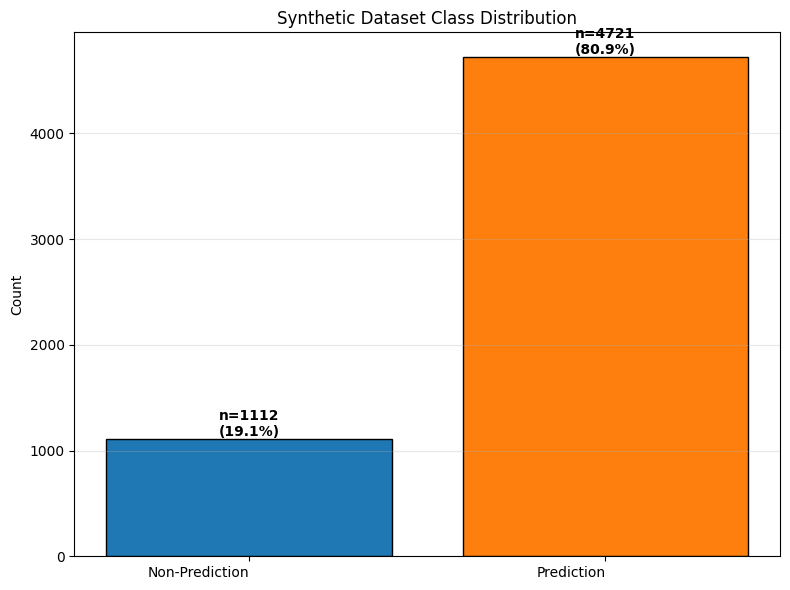


Ground Truth distribution:
Ground Truth
1    4721
0    1112
Name: count, dtype: int64

Preview:
                                       Base Sentence  Ground Truth   Domain  \
0  Sebastian, a financial analyst forecasts that ...             1  finance   
1  On August 22, 2024, Goldman Sachs speculates t...             1  finance   
2  Citigroup predicts on September 15, 2026, the ...             1  finance   
3  According to Morgan Stanley, the projected rev...             1  finance   
4  In 2029 Q4, David envisions that the dividend ...             1  finance   
5  Google stock price will decrease in December 2...             1  finance   
6  JPMorgan forecasts that the revenue at Boeing ...             1  finance   

                Model Name    API Name  Batch ID  Temperature  Top P  \
0     llama-3.1-8b-instant  GROQ_CLOUD         1          0.1    1.0   
1     llama-3.1-8b-instant  GROQ_CLOUD         1          0.1    1.0   
2     llama-3.1-8b-instant  GROQ_CLOUD         1      

,Base Sentence,Ground Truth,Domain,Model Name,API Name,Batch ID,Temperature,Top P,Generated At,Prompt Used,Template Number,Prediction Date,Template Text,Dataset Name
0,"Sebastian, a financial analyst forecasts that ...",1,finance,llama-3.1-8b-instant,GROQ_CLOUD,1,0.1,1.0,2026-02-28,"A prediction <p> = (<p_s>, <p_t>, <p_d>, <p_o>...",1,NaN,NaN,synthetic
1,"On August 22, 2024, Goldman Sachs speculates t...",1,finance,llama-3.1-8b-instant,GROQ_CLOUD,1,0.1,1.0,2026-02-28,"A prediction <p> = (<p_s>, <p_t>, <p_d>, <p_o>...",2,NaN,NaN,synthetic
2,"Citigroup predicts on September 15, 2026, the ...",1,finance,llama-3.1-8b-instant,GROQ_CLOUD,1,0.1,1.0,2026-02-28,"A prediction <p> = (<p_s>, <p_t>, <p_d>, <p_o>...",3,NaN,NaN,synthetic
3,"According to Morgan Stanley, the projected rev...",1,finance,llama-3.1-8b-instant,GROQ_CLOUD,1,0.1,1.0,2026-02-28,"A prediction <p> = (<p_s>, <p_t>, <p_d>, <p_o>...",4,NaN,NaN,synthetic
4,"In 2029 Q4, David envisions that the dividend ...",1,finance,llama-3.1-8b-instant,GROQ_CLOUD,1,0.1,1.0,2026-02-28,"A prediction <p> = (<p_s>, <p_t>, <p_d>, <p_o>...",5,NaN,NaN,synthetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5828,"On Q2 of 2025, Coach Ryan Thompson observed th...",0,sport,llama-3.1-8b-instant,GROQ_CLOUD,0,NaN,NaN,NaN,NaN,2,NaN,NaN,synthetic
5829,"George noted that on August 28, 2024, the save...",0,sport,llama-3.1-8b-instant,GROQ_CLOUD,0,NaN,NaN,NaN,NaN,3,NaN,NaN,synthetic
5830,According to the staff of the Los Angeles Lake...,0,sport,llama-3.1-8b-instant,GROQ_CLOUD,0,NaN,NaN,NaN,NaN,4,NaN,NaN,synthetic
5831,"In Q4 of 2027, Analyst Daniel Kim recorded tha...",0,sport,llama-3.1-8b-instant,GROQ_CLOUD,0,NaN,NaN,NaN,NaN,5,NaN,NaN,synthetic


In [3]:
df = DataProcessing.load_synthetic_dataset(notebook_dir)
df

In [4]:
# train_sentence_label_df = DataProcessing.drop_df_columns(train_base_df, drop_cols)
# test_sentence_label_df = DataProcessing.drop_df_columns(test_base_df, drop_cols)
# test_sentence_label_df

df = DataProcessing.drop_df_columns(df, df.columns.to_list()[2:])
df

,Base Sentence,Ground Truth
0,"Sebastian, a financial analyst forecasts that ...",1
1,"On August 22, 2024, Goldman Sachs speculates t...",1
2,"Citigroup predicts on September 15, 2026, the ...",1
3,"According to Morgan Stanley, the projected rev...",1
4,"In 2029 Q4, David envisions that the dividend ...",1
...,...,...
5828,"On Q2 of 2025, Coach Ryan Thompson observed th...",0
5829,"George noted that on August 28, 2024, the save...",0
5830,According to the staff of the Los Angeles Lake...,0
5831,"In Q4 of 2027, Analyst Daniel Kim recorded tha...",0


In [5]:
X_train_df, X_test_df, y_train_df, y_test_df = DataProcessing.split_data(df, df[['Ground Truth']], random_state=40, test_size=.2)

In [6]:
train_df = X_train_df.copy()
train_df['label'] = X_train_df['Ground Truth'] 
train_dataset = Dataset.from_pandas(train_df)
train_dataset

Dataset({
    features: ['Base Sentence', 'Ground Truth', 'label', '__index_level_0__'],
    num_rows: 4666
})

In [ ]:
test_df = X_test_df.copy()
test_df['label'] = y_test_df['Ground Truth']
test_df = test_df[['Base Sentence', 'Ground Truth', 'label']]
test_dataset = Dataset.from_pandas(test_df)
test_dataset

Dataset({
    features: ['Base Sentence', 'Ground Truth', 'label', '__index_level_0__'],
    num_rows: 1167
})

In [8]:
dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['Base Sentence', 'Ground Truth', 'label', '__index_level_0__'],
        num_rows: 4666
    })
    test: Dataset({
        features: ['Base Sentence', 'Ground Truth', 'label', '__index_level_0__'],
        num_rows: 1167
    })
})

In [9]:
train_test_p_o_path = os.path.join(base_data_path, 'text_classification_tutorial/')
dataset_dict.save_to_disk(train_test_p_o_path)

Saving the dataset (0/1 shards):   0%|          | 0/4666 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1167 [00:00<?, ? examples/s]

In [10]:
import json

all_data = {}
for split_name, dataset in dataset_dict.items():
    all_data[split_name] = dataset.to_list()

    # write split to a json
    with open(f"../data/text_classification_tutorial/{split_name}_dict-v2.json", "w", encoding="utf-8") as badbitches:
        # write each sp
        json.dump(all_data.get(split_name), badbitches, indent=2, ensure_ascii=False)
    # empty dict
    all_data = {}


In [ ]:
all_data